
Initial Demand:
[[ 2065.     590.    3245.  ]
 [ 3500.    1000.    5500.  ]
 [ 1225.    3500.    2625.  ]
 [ 1225.    3500.    2625.  ]
 [ 7500.       0.   12500.  ]
 [ 1695.       0.    3955.  ]
 [ 3750.    2250.    9000.  ]
 [ 8252.75  4539.01 15005.  ]
 [ 1250.     600.    3150.  ]
 [ 9632.    3440.   21328.  ]
 [ 3032.     614.    1554.  ]
 [  734.      99.    1250.  ]
 [ 2112.    1056.    4800.  ]
 [ 1320.     660.    3000.  ]
 [ 1980.     990.    4500.  ]
 [ 1380.     552.    2760.  ]
 [  233.      24.     357.  ]
 [  238.      85.     527.  ]
 [  594.    1500.    1320.  ]]

Best Fitness per Generation (Best so far):
Generation 1: 1406977.6357800001
Generation 2: 1406977.6357800001
Generation 3: 1352805.4947600008
Generation 4: 1295316.28278
Generation 5: 1295316.28278
Generation 6: 1295316.28278
Generation 7: 1295316.28278
Generation 8: 1295316.28278
Generation 9: 1295316.28278
Generation 10: 1295316.28278
Generation 11: 1293304.6047600005
Generation 12: 1293304.6047600005
Gene

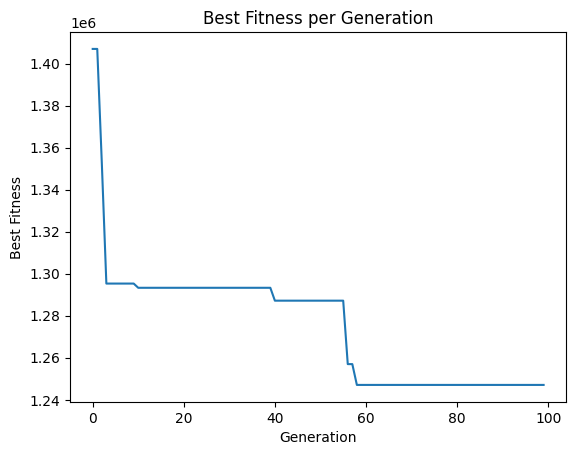

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Parameters
NUM_SOURCES = 6
NUM_DESTINATIONS = 19
NUM_SHIPS = 2
NUM_GOODS = 3
COST_PER_DAY_AT_SEA = 6752.16
DAYS_AT_SEA = np.array([
    [0, 1.9, 4.3, 5.2, 9.2, 8.6, 1.2, 0.9, 2.5, 4, 0.9, 3.6, 0.85, 3, 4.8, 2.9, 6.1, 6, 7.6, 10.8, 4.8, 5.4, 6.8, 11.6, 7],
    [1.9, 0, 2.9, 4.3, 1.7, 10, 3.1, 1.1, 1.1, 3.2, 2.8, 2.2, 1.1, 1.7, 3.4, 1.4, 4.4, 4.4, 9.2, 9.3, 3.7, 4.2, 6.9, 10.1, 6.9],
    [4.3, 2.9, 0, 5.4, 2, 7.7, 5.9, 4, 2.3, 3.5, 3.2, 2.6, 3.9, 1.4, 3.3, 1.7, 1.6, 1.5, 7.1, 7, 4.8, 5.1, 4.1, 8, 8],
    [5.2, 4.3, 5.4, 0, 3.5, 5.7, 7.1, 5.1, 3.9, 2.5, 3.9, 3.1, 5.2, 4.6, 6.3, 3.7, 6.9, 6.9, 4.9, 5, 0.7, 1.4, 6.8, 5.8, 2.6],
    [9.2, 1.7, 2, 3.5, 0, 9.2, 4.7, 2.7, 1, 1.6, 1.3, 0.6, 2.7, 2.2, 3.1, 0.3, 3.6, 3.5, 8.4, 8.5, 2.9, 3.2, 6.1, 9.3, 6.1],
    [8.6, 10, 7.7, 5.7, 9.2, 0, 12.3, 10.2, 9.6, 8.2, 8.3, 8.8, 10.3, 9.1, 11, 9.4, 6.1, 6.5, 6.5, 3.2, 6.3, 6.3, 3.6, 4, 3],
    [1.2, 3.1, 5.9, 7.1, 4.7, 12.3, 0, 2.1, 4.2, 6.2, 11, 5.3, 2, 2.5, 3.8, 4.4, 7.5, 7.5, 12, 12.2, 6.5, 7.1, 10, 13, 9.8],
    [0.9, 1.1, 4, 5.1, 2.7, 10.2, 2.1, 0, 2.2, 4.2, 3.8, 3.3, 0.1, 0.6, 4.5, 2.4, 5.5, 5.5, 9.9, 10.1, 4.5, 5.1, 8, 11, 7.7],
    [2.5, 1.1, 2.3, 3.9, 1, 9.6, 4.2, 2.2, 0, 2.5, 2.2, 1.6, 2.2, 1.6, 2.9, 0.7, 3.8, 3.8, 8.8, 9, 3.3, 3.6, 6.4, 9.8, 6.6],
    [4, 3.2, 3.5, 2.5, 1.6, 8.2, 6.2, 4.2, 2.5, 0, 6.4, 1.2, 4.2, 2.7, 4.6, 1.8, 5.1, 5.1, 7.4, 7.5, 1.9, 2.2, 7.6, 8.3, 5.1],
    [0.9, 2.8, 3.2, 3.9, 1.3, 8.3, 11, 3.8, 2.2, 6.4, 0, 0.9, 3.9, 2.4, 4.3, 1.5, 4.7, 4.7, 7.6, 7.7, 2, 2.3, 7.2, 8.5, 5.3],
    [3.6, 2.2, 2.6, 3.1, 0.6, 8.8, 5.3, 3.3, 1.6, 1.2, 0.9, 0, 3.3, 1.8, 3.7, 0.9, 4.1, 4.1, 8.1, 8.2, 2.5, 2.8, 6.6, 9, 5.8],
    [0.85, 1.1, 3.9, 5.2, 2.7, 10.3, 2, 0.1, 2.2, 4.2, 3.9, 3.3, 0, 2.8, 4.5, 2.4, 5.5, 5.5, 10, 10.2, 4.5, 5.1, 8, 11, 7.8],
    [3, 1.7, 1.4, 4.6, 2.2, 9.1, 2.5, 0.6, 1.6, 2.7, 2.4, 1.8, 2.8, 0, 2.1, 0.9, 2.9, 2.9, 8.5, 8.4, 3.9, 4.2, 5.4, 9.4, 7.2],
    [4.8, 3.4, 3.3, 6.3, 3.1, 11, 3.8, 4.5, 2.9, 4.6, 4.3, 3.7, 4.5, 2.1, 0, 2.8, 4.9, 4.8, 10.4, 10.3, 5.7, 6, 7.4, 11.3, 8.9],
    [2.9, 1.4, 1.7, 3.7, 0.3, 9.4, 4.4, 2.4, 0.7, 1.8, 1.5, 0.9, 2.4, 0.9, 2.8, 0, 3.3, 3.2, 8.6, 8.7, 3.1, 3.4, 5.8, 9.5, 6.3],
    [6.1, 4.4, 1.6, 6.9, 3.6, 6.1, 7.5, 5.5, 3.8, 5.1, 4.7, 4.1, 5.5, 2.9, 4.9, 3.3, 0, 0.4, 5.6, 5.4, 6.3, 6.6, 2.5, 6.4, 6.7],
    [6, 4.4, 1.5, 6.9, 3.5, 6.5, 7.5, 5.5, 3.8, 5.1, 4.7, 4.1, 5.5, 2.9, 4.8, 3.2, 0.4, 0, 5.9, 5.8, 6.3, 6.6, 2.9, 6.8, 7],
    [7.6, 9.2, 7.1, 4.9, 8.4, 6.5, 12, 9.9, 8.8, 7.4, 7.6, 8.1, 10, 8.5, 10.4, 8.6, 5.6, 5.9, 0, 2.4, 5.6, 5.6, 3, 3.4, 2.3],
    [10.8, 9.3, 7, 5, 8.5, 3.2, 12.2, 10.1, 9, 7.5, 7.7, 8.2, 10.2, 8.4, 10.3, 8.7, 5.4, 5.8, 2.4, 0, 5.7, 5.7, 2.9, 1.4, 2.4],
    [4.8, 3.7, 4.8, 0.7, 2.9, 6.3, 6.5, 4.5, 3.3, 1.9, 2, 2.5, 4.5, 3.9, 5.7, 3.1, 6.3, 6.3, 5.6, 5.7, 0, 1.1, 7.5, 6.5, 3.3],
    [5.4, 4.2, 5.1, 1.4, 3.2, 6.3, 7.1, 5.1, 3.6, 2.2, 2.3, 2.8, 5.1, 4.2, 6, 3.4, 6.6, 6.6, 5.6, 5.7, 1.1, 0, 7.5, 6.5, 3.3],
    [6.8, 6.9, 4.1, 6.8, 6.1, 3.6, 10, 8, 6.4, 7.6, 7.2, 6.6, 8, 5.4, 7.4, 5.8, 2.5, 2.9, 3, 2.9, 7.5, 7.5, 0, 3.9, 4.2],
    [11.6, 10.1, 8, 5.8, 9.3, 4, 13, 11, 9.8, 8.3, 8.5, 9, 11, 9.4, 11.3, 9.5, 6.4, 6.8, 3.4, 1.4, 6.5, 6.5, 3.9, 0, 3.2],
    [7, 6.9, 8, 2.6, 6.1, 3, 9.8, 7.7, 6.6, 5.1, 5.3, 5.8, 7.8, 7.2, 8.9, 6.3, 6.7, 7, 2.3, 2.4, 3.3, 3.3, 4.2, 3.2, 0]
])
DEMAND = np.array([
    [2065, 590, 3245], [3500, 1000, 5500], [1225, 3500, 2625], [1225, 3500, 2625], [7500, 0, 12500],
    [1695, 0, 3955], [3750, 2250, 9000], [8252.75, 4539.01, 15005], [1250, 600, 3150],
    [9632, 3440, 21328], [3032, 614, 1554], [734, 99, 1250], [2112, 1056, 4800],
    [1320, 660, 3000], [1980, 990, 4500], [1380, 552, 2760], [233, 24, 357],
    [238, 85, 527], [594, 1500, 1320]
])
LOADING_UNLOADING_COST = np.array([0.009, 0.0135])
CAPACITY = np.array([
    [10008, 7149, 7149],
    [14506, 13056, 14505]
])

POPULATION_SIZE = 100
NUM_GENERATIONS = 100
MUTATION_RATE = 0.01

# Initialize remaining demand as a copy of the original demand
remaining_demand = np.copy(DEMAND)

# Helper function to calculate remaining demand
def calculate_remaining_demand(individual):
    global remaining_demand
    remaining_demand_copy = np.copy(remaining_demand)
    for ship_index, route in enumerate(individual):
        for port in route:
            if port >= NUM_SOURCES:
                destination_index = port - NUM_SOURCES
                remaining_demand_copy[destination_index] -= DEMAND[destination_index]
    # Set negative values to zero
    remaining_demand_copy[remaining_demand_copy < 0] = 0
    return remaining_demand_copy

# Initial Population
def initialize_population():
    population = []
    for _ in range(POPULATION_SIZE):
        individual = []
        for ship in range(NUM_SHIPS):
            route = random.sample(range(NUM_SOURCES + NUM_DESTINATIONS), NUM_SOURCES + NUM_DESTINATIONS)
            individual.append(route)
        population.append(individual)
    return population

# Calculate Total Days at Sea
def calculate_total_days_at_sea_for_ships(individual):
    total_days = []
    for ship_index, route in enumerate(individual):
        ship_total_days = 0
        previous_port = route[0]
        for port in route[1:]:
            ship_total_days += DAYS_AT_SEA[previous_port][port]
            previous_port = port
        total_days.append(ship_total_days)
    return total_days

# Fitness Function
def calculate_fitness(individual):
    total_cost = 0
    total_penalty = 0
    for ship_index, route in enumerate(individual):
        ship_capacity = CAPACITY[ship_index]
        current_capacity = [0, 0, 0]
        previous_port = route[0]
        for port in route[1:]:
            if port < NUM_SOURCES:
                # Loading goods
                for good in range(NUM_GOODS):
                    current_capacity[good] += DEMAND[port][good]
                    total_cost += LOADING_UNLOADING_COST[0] * DEMAND[port][good]
            else:
                # Unloading goods
                destination_index = port - NUM_SOURCES
                for good in range(NUM_GOODS):
                    current_capacity[good] -= DEMAND[destination_index][good]
                    total_cost += LOADING_UNLOADING_COST[1] * DEMAND[destination_index][good]
            # Check capacity constraints
            if any(current_capacity[good] > ship_capacity[good] for good in range(NUM_GOODS)):
                total_cost += 1e6  # Penalize heavily if capacity exceeded
            # Calculate sea travel costs
            if previous_port < NUM_SOURCES and port < NUM_SOURCES:
                total_cost += DAYS_AT_SEA[previous_port][port] * COST_PER_DAY_AT_SEA
            elif previous_port < NUM_SOURCES and port >= NUM_SOURCES:
                total_cost += DAYS_AT_SEA[previous_port][port] * COST_PER_DAY_AT_SEA
            elif previous_port >= NUM_SOURCES and port < NUM_SOURCES:
                total_cost += DAYS_AT_SEA[previous_port][port] * COST_PER_DAY_AT_SEA
            else:
                total_cost += DAYS_AT_SEA[previous_port][port] * COST_PER_DAY_AT_SEA
            previous_port = port

        # Calculate penalty for remaining demand
        remaining_demand_copy = calculate_remaining_demand(individual)
        total_penalty += 1e6 * np.sum(remaining_demand_copy)  # Penalize 1 million for each unit of unfulfilled demand

    total_cost += total_penalty  # Add penalty to total cost
    return total_cost  # We use negative because we want to minimize cost

# Selection of Parent
def selection(population, fitnesses):
    selected = random.choices(population, weights=fitnesses, k=POPULATION_SIZE)
    return selected

# Crossover Function
def crossover(parent1, parent2):
    crossover_point = random.randint(0, len(parent1[0]) - 1)
    child1 = [parent1[0][:crossover_point] + parent2[0][crossover_point:], parent1[1][:crossover_point] + parent2[1][crossover_point:]]
    child2 = [parent2[0][:crossover_point] + parent1[0][crossover_point:], parent2[1][:crossover_point] + parent1[1][crossover_point:]]
    return child1, child2

# Mutation Function
def mutate(individual):
    if random.random() < MUTATION_RATE:
        for ship in range(NUM_SHIPS):
            idx1, idx2 = random.sample(range(len(individual[ship])), 2)
            individual[ship][idx1], individual[ship][idx2] = individual[ship][idx2], individual[ship][idx1]

# Genetic Algorithm
population = initialize_population()
best_fitness_per_generation = []
best_fitness_so_far = float('inf')

for generation in range(NUM_GENERATIONS):
    fitnesses = [calculate_fitness(ind) for ind in population]
    best_fitness_current_gen = min(fitnesses)

    # Update best fitness so far
    if best_fitness_current_gen < best_fitness_so_far:
        best_fitness_so_far = best_fitness_current_gen
        best_individual_so_far = population[np.argmin(fitnesses)]

    best_fitness_per_generation.append(best_fitness_so_far)

    next_generation = []
    for i in range(0, POPULATION_SIZE, 2):
        parent1, parent2 = population[i], population[i + 1]
        child1, child2 = crossover(parent1, parent2)
        mutate(child1)
        mutate(child2)
        next_generation.append(child1)
        next_generation.append(child2)
    population = next_generation

# Initialize best individual found and best fitness so far
best_individual_so_far = None
best_fitness_so_far = float('inf')
best_fitness_per_generation = []

for generation in range(NUM_GENERATIONS):
    fitnesses = [calculate_fitness(ind) for ind in population]
    best_fitness_current_gen = min(fitnesses)

    # Update best individual found so far
    if best_fitness_current_gen < best_fitness_so_far:
        best_fitness_so_far = best_fitness_current_gen
        best_individual_so_far = population[np.argmin(fitnesses)]

    # Always add the best fitness so far to the list
    best_fitness_per_generation.append(best_fitness_so_far)

    next_generation = []
    for i in range(0, POPULATION_SIZE, 2):
        parent1, parent2 = population[i], population[i + 1]
        child1, child2 = crossover(parent1, parent2)
        mutate(child1)
        mutate(child2)
        next_generation.append(child1)
        next_generation.append(child2)
    population = next_generation

# Find Best Route
best_individual = best_individual_so_far if best_individual_so_far is not None else min(population, key=calculate_fitness)
best_fitness = calculate_fitness(best_individual)
best_route = np.array(best_individual)+1
total_days_at_sea = calculate_total_days_at_sea_for_ships(best_individual)

print("\nInitial Demand:")
print(DEMAND)

# Print best fitness per generation
print("\nBest Fitness per Generation (Best so far):")
for gen, fitness in enumerate(best_fitness_per_generation):
    print(f"Generation {gen + 1}: {fitness}")

print(f"Best Route: {best_route.tolist()}")
print(f"Best Fitness: {best_fitness}")
for ship_index, days in enumerate(total_days_at_sea):
    print(f"Total days at sea for Ship {ship_index + 1}: {days}")

# Calculate and print remaining demand after best solution is found
remaining_demand_final = calculate_remaining_demand(best_individual)
print("\nRemaining Demand after Best Solution is Found:")
print(remaining_demand_final)

# Plot Best Fitness
plt.plot(best_fitness_per_generation)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Best Fitness per Generation')
plt.show()